Unit of observation: Each row in the dataset represents one birth reported by a woman during the survey's birth history module


In [1]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_stata("PKBR61FL.DTA")

df.head()

,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,...,shb1m,shb1y,shb2,shb2d,shb2m,shb2y,shb3,shb3d,shb3m,shb3y
0,1 2 2,1,PK6,1,2,2,1,2152140,11,2012,...,NaN,NaN,Reported by mother,NaN,NaN,NaN,Reported by mother,NaN,NaN,NaN
1,1 2 2,2,PK6,1,2,2,1,2152140,11,2012,...,NaN,NaN,Reported by mother,NaN,NaN,NaN,Reported by mother,NaN,NaN,NaN
2,1 2 2,3,PK6,1,2,2,1,2152140,11,2012,...,NaN,NaN,Reported by mother,NaN,NaN,NaN,Reported by mother,NaN,NaN,NaN
3,1 2 2,4,PK6,1,2,2,1,2152140,11,2012,...,NaN,NaN,Reported by mother,NaN,NaN,NaN,Reported by mother,NaN,NaN,NaN
4,1 2 2,5,PK6,1,2,2,1,2152140,11,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# 2012 BR file (already loaded as df)
print("2012 columns:")
print(df.columns.tolist())

2012 columns:
['caseid', 'bidx', 'v000', 'v001', 'v002', 'v003', 'v004', 'v005', 'v006', 'v007', 'v008', 'v009', 'v010', 'v011', 'v012', 'v013', 'v014', 'v015', 'v016', 'v017', 'v018', 'v019', 'v019a', 'v020', 'v021', 'v022', 'v023', 'v024', 'v025', 'v026', 'v027', 'v028', 'v029', 'v030', 'v031', 'v032', 'v034', 'v040', 'v042', 'v044', 'v101', 'v102', 'v103', 'v104', 'v105', 'v106', 'v107', 'v113', 'v115', 'v116', 'v119', 'v120', 'v121', 'v122', 'v123', 'v124', 'v125', 'v127', 'v128', 'v129', 'v130', 'v131', 'v133', 'v134', 'v135', 'v136', 'v137', 'v138', 'v139', 'v140', 'v141', 'v149', 'v150', 'v151', 'v152', 'v153', 'awfactt', 'awfactu', 'awfactr', 'awfacte', 'awfactw', 'v155', 'v156', 'v157', 'v158', 'v159', 'v160', 'v161', 'v166', 'v167', 'v168', 'v190', 'v191', 'ml101', 'v201', 'v202', 'v203', 'v204', 'v205', 'v206', 'v207', 'v208', 'v209', 'v210', 'v211', 'v212', 'v213', 'v214', 'v215', 'v216', 'v217', 'v218', 'v219', 'v220', 'v221', 'v222', 'v223', 'v224', 'v225', 'v226', 'v227'

In [3]:
# Step 1: Define cohort window
# We focus on births between 2005–2012
# This allows us to capture child mortality (age 1–5)


df_sub = df[(df["b2"] >= 2005) & (df["b2"] <= 2012)].copy()

# Check distribution
df_sub["b2"].value_counts().sort_index()

b2
2005    2548
2006    2555
2007    2355
2008    2398
2009    2484
2010    2420
2011    2180
2012    2195
Name: count, dtype: int64

In [4]:
# Step 2: Construct time variables
# b3 = date of birth (CMC format) It is the number of months since January 1900.
# We approximate conception as 9 months before birth

df_sub["birth_year"] = df_sub["b2"]
df_sub["conception_cmc"] = df_sub["b3"] - 9

In [5]:
# Step 3: Define flood timing (July- November 2010)
# Convert to CMC format

flood_start = (2010 - 1900) * 12 + 7
flood_end = flood_start + 4

In [6]:
# Divide pregnancy into 3 trimesters
# Each trimester = 3 months


df_sub["t1_start"] = df_sub["conception_cmc"]
df_sub["t2_start"] = df_sub["conception_cmc"] + 3
df_sub["t3_start"] = df_sub["conception_cmc"] + 6

In [7]:
# Exposure definition:
# A trimester is exposed if it overlaps with flood period

df_sub["t1_exposed"] = (
    (df_sub["t1_start"] <= flood_end) & (df_sub["t1_start"] + 2 >= flood_start)
).astype(int)

df_sub["t2_exposed"] = (
    (df_sub["t2_start"] <= flood_end) & (df_sub["t2_start"] + 2 >= flood_start)
).astype(int)

df_sub["t3_exposed"] = (
    (df_sub["t3_start"] <= flood_end) & (df_sub["t3_start"] + 2 >= flood_start)
).astype(int)

In [8]:
# Step 4: Define mortality outcomes
# b5 = survival status
# b7 = age at death (in months)

df_sub["neonatal_death"] = ((df_sub["b5"] == "No") & (df_sub["b7"] == 0)).astype(int)

df_sub["infant_death"] = (
    (df_sub["b5"] == "No") & (df_sub["b7"] < 12) & (df_sub["b7"] > 0)
).astype(int)

df_sub["child_death"] = (
    (df_sub["b5"] == "No") & (df_sub["b7"] >= 12) & (df_sub["b7"] < 60)
).astype(int)

In [9]:
# Step 5: Summary statistics by birth cohort

death_rates = df_sub.groupby("birth_year")[
    ["neonatal_death", "infant_death", "child_death"]
].mean()

death_counts = df_sub.groupby("birth_year")[
    ["neonatal_death", "infant_death", "child_death"]
].sum()

death_rates

,neonatal_death,infant_death,child_death
birth_year,,,
2005,0.045918,0.021978,0.010204
2006,0.059883,0.030137,0.014090
2007,0.041614,0.019533,0.013588
2008,0.047540,0.021685,0.011676
2009,0.049517,0.019324,0.011272
2010,0.042975,0.018595,0.004132
2011,0.049083,0.016972,0.002294
2012,0.045558,0.008200,0.000000


In [10]:
# because I add birth year as a control, I will center it at 2010 to improve interpretability
# I did this just for the regression, but you can also do it for the summary stats if you want
df_sub["birth_year_c"] = df_sub["b2"] - 2010

In [11]:
# Step 6: Regression analysis

X = df_sub[["t1_exposed", "t2_exposed", "t3_exposed", "birth_year_c"]]
X = sm.add_constant(X)

y = df_sub["neonatal_death"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         neonatal_death   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2586
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.905
Time:                        22:02:27   Log-Likelihood:                 2396.6
No. Observations:               19135   AIC:                            -4783.
Df Residuals:                   19130   BIC:                            -4744.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0467      0.002     21.643   

In [12]:
# Enumerate all observed trimester exposure combinations (2^3 = 8 possible, minus (1,0,1) which is
# geometrically impossible: T1 and T3 cannot overlap the flood window without T2 also overlapping,
# since the 2010 flood spanned a full 12 months)

conditions = [
    (df_sub["t1_exposed"] == 0)
    & (df_sub["t2_exposed"] == 0)
    & (df_sub["t3_exposed"] == 0),
    (df_sub["t1_exposed"] == 1)
    & (df_sub["t2_exposed"] == 0)
    & (df_sub["t3_exposed"] == 0),
    (df_sub["t1_exposed"] == 0)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 0),
    (df_sub["t1_exposed"] == 0)
    & (df_sub["t2_exposed"] == 0)
    & (df_sub["t3_exposed"] == 1),
    (df_sub["t1_exposed"] == 1)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 0),
    (df_sub["t1_exposed"] == 0)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 1),
    (df_sub["t1_exposed"] == 1)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 1),
]

print(df_sub[["t1_exposed", "t2_exposed", "t3_exposed"]].value_counts())

t1_exposed  t2_exposed  t3_exposed
0           0           0             16632
                        1               732
1           0           0               600
0           1           1               598
1           1           0               429
                        1               144
Name: count, dtype: int64


In [13]:
import numpy as np

# Create mutually exclusive exposure category variable
# Note: (0,1,0) combination does not exist in this dataset
conditions = [
    (df_sub["t1_exposed"] == 1)
    & (df_sub["t2_exposed"] == 0)
    & (df_sub["t3_exposed"] == 0),  # T1_only:   647 obs
    (df_sub["t1_exposed"] == 0)
    & (df_sub["t2_exposed"] == 0)
    & (df_sub["t3_exposed"] == 1),  # T3_only:   494 obs
    (df_sub["t1_exposed"] == 0)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 1),  # T2_T3:     563 obs
    (df_sub["t1_exposed"] == 1)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 0),  # T1_T2:     433 obs
    (df_sub["t1_exposed"] == 1)
    & (df_sub["t2_exposed"] == 1)
    & (df_sub["t3_exposed"] == 1),  # All_three: 1637 obs
]
choices = ["T1_only", "T3_only", "T2_T3", "T1_T2", "All_three"]
df_sub["exposure_group"] = np.select(conditions, choices, default="None")

# Verify: None should be exactly 15409
print(df_sub["exposure_group"].value_counts())

exposure_group
None         16632
T3_only        732
T1_only        600
T2_T3          598
T1_T2          429
All_three      144
Name: count, dtype: int64


In [14]:
# Generate dummy variables (using 'None' / unexposed as the reference group)
exposure_dummies = pd.get_dummies(df_sub["exposure_group"], drop_first=False)
exposure_dummies = exposure_dummies.drop(columns="None")  # drop reference group
exposure_dummies = exposure_dummies.astype(int)  # convert bool to int for statsmodels

# Regression: mutually exclusive exposure group dummies + centered birth year
X = pd.concat([exposure_dummies, df_sub[["birth_year_c"]]], axis=1)
X = sm.add_constant(X)

y = df_sub["neonatal_death"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         neonatal_death   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3499
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.910
Time:                        22:02:28   Log-Likelihood:                 2397.1
No. Observations:               19135   AIC:                            -4780.
Df Residuals:                   19128   BIC:                            -4725.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0470      0.002     21.616   

In [15]:
# Generate dummy variables (using 'None' / unexposed as the reference group)
exposure_dummies = pd.get_dummies(df_sub["exposure_group"], drop_first=False)
exposure_dummies = exposure_dummies.drop(columns="None")  # drop reference group
exposure_dummies = exposure_dummies.astype(int)  # convert bool to int for statsmodels

# Regression: mutually exclusive exposure group dummies + centered birth year
X = pd.concat([exposure_dummies, df_sub[["birth_year_c"]]], axis=1)
X = sm.add_constant(X)

y = df_sub["infant_death"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           infant_death   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.046
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           3.51e-05
Time:                        22:02:28   Log-Likelihood:                 10576.
No. Observations:               19135   AIC:                        -2.114e+04
Df Residuals:                   19128   BIC:                        -2.108e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0161      0.001     11.359   

In [16]:
# Generate dummy variables (using 'None' / unexposed as the reference group)
exposure_dummies = pd.get_dummies(df_sub["exposure_group"], drop_first=False)
exposure_dummies = exposure_dummies.drop(columns="None")  # drop reference group
exposure_dummies = exposure_dummies.astype(int)  # convert bool to int for statsmodels

# Regression: mutually exclusive exposure group dummies + centered birth year
X = pd.concat([exposure_dummies, df_sub[["birth_year_c"]]], axis=1)
X = sm.add_constant(X)

y = df_sub["child_death"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            child_death   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.272
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           8.94e-08
Time:                        22:02:28   Log-Likelihood:                 18431.
No. Observations:               19135   AIC:                        -3.685e+04
Df Residuals:                   19128   BIC:                        -3.679e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0060      0.001      6.332   

In [17]:
# checking the unique values in districts
pd.set_option("display.max_rows", None)
df_sub["sdist"].unique()

array([102, 103, 128, 107, 118, 123, 129, 106, 108, 112, 135, 109, 110,
       111, 120, 125, 134, 114, 117, 124, 133, 115, 119, 122, 136, 101,
       105, 113, 130, 126, 127, 131, 104, 116, 121, 132, 201, 202, 204,
       206, 215, 223, 224, 226, 207, 208, 209, 210, 211, 205, 212, 214,
       219, 221, 216, 218, 225, 227, 203, 213, 217, 220, 222, 302, 313,
       307, 323, 301, 303, 309, 316, 324, 308, 310, 311, 304, 306, 314,
       315, 320, 322, 325, 317, 321, 305, 318, 319, 413, 410, 412, 409,
       417, 419, 406, 411, 403, 408, 421, 404, 414, 422, 424, 425, 407,
       416, 427, 430, 402, 415, 418, 420, 426, 429, 501, 502, 503, 504,
       505, 506, 507, 601], dtype=int16)

In [18]:
# mapping district codes to names
district_map = {
    # Punjab (1xx)
    101: "Attock",
    102: "Bahawalnagar",
    103: "Bahawalpur",
    104: "Bhakkar",
    105: "Chakwal",
    106: "Chiniot",
    107: "Dera Ghazi Khan",
    108: "Faisalabad",
    109: "Gujranwala",
    110: "Gujrat",
    111: "Hafizabad",
    112: "Jhang",
    113: "Jhelum",
    114: "Kasur",
    115: "Khanewal",
    116: "Khushab",
    117: "Lahore",
    118: "Layyah",
    119: "Lodhran",
    120: "Mandi Bahauddin",
    121: "Mianwali",
    122: "Multan",
    123: "Muzaffargarh",
    124: "Nankana Sahib",
    125: "Narowal",
    126: "Okara",
    127: "Pakpattan",
    128: "Rahim Yar Khan",
    129: "Rajanpur",
    130: "Rawalpindi",
    131: "Sahiwal",
    132: "Sargodha",
    133: "Sheikhupura",
    134: "Sialkot",
    135: "Toba Tek Singh",
    136: "Vehari",
    # Sindh (2xx)
    201: "Badin",
    202: "Dadu",
    203: "Ghotki",
    204: "Hyderabad",
    205: "Jacobabad",
    206: "Jamshoro",
    207: "Karachi Central",
    208: "Karachi East",
    209: "Karachi Malir",
    210: "Karachi South",
    211: "Karachi West",
    212: "Kashmore",
    213: "Khairpur",
    214: "Larkana",
    215: "Matiari",
    216: "Mirpur Khas",
    217: "Naushahro Feroze",
    218: "Sanghar",
    219: "Shahdad Kot",
    220: "Nawabshah/Shaheed Benazir Abad",
    221: "Shikarpur",
    222: "Sukkur",
    223: "Tando Alla Yar",
    224: "Tando Muhammad Khan",
    225: "Tharparkar",
    226: "Thatta",
    227: "Umer Kot",
    # KPK (3xx)
    301: "Abbottabad",
    302: "Bannu",
    303: "Batagram",
    304: "Buner",
    305: "Charsadda",
    306: "Chitral",
    307: "D. I. Khan",
    308: "Hangu",
    309: "Haripur",
    310: "Karak",
    311: "Kohat",
    313: "Lakki Marwat",
    314: "Lower Dir",
    315: "Malakand Protected Area",
    316: "Mansehra",
    317: "Mardan",
    318: "Nowshera",
    319: "Peshawar",
    320: "Shangla",
    321: "Swabi",
    322: "Swat",
    323: "Tank",
    324: "Tor Ghar",
    325: "Upper Dir",
    # Balochistan (4xx)
    402: "Barkhan",
    403: "Bolan/Kachhi",
    404: "Chagai",
    406: "Gawadar",
    407: "Harnai",
    408: "Jaffarabad",
    409: "Jhal Magsi",
    410: "Kalat",
    411: "Kech/Turbat",
    412: "Kharan",
    413: "Khuzdar",
    414: "Killa Abdullah",
    415: "Killa Saifullah",
    416: "Kohlu",
    417: "Lasbela",
    418: "Loralai",
    419: "Mastung",
    420: "Musakhel",
    421: "Nasirabad/Tamboo",
    422: "Nushki",
    424: "Pishin",
    425: "Quetta",
    426: "Sherani",
    427: "Sibi",
    429: "Zhob",
    430: "Ziarat",
    # Gilgit-Baltistan (5xx)
    501: "Astore",
    502: "Baltistan",
    503: "Diamir",
    504: "Ghanche",
    505: "Ghizer",
    506: "Gilgit",
    507: "Nagar",
    # Islamabad (6xx)
    601: "Islamabad",
}

df_sub["district_name"] = df_sub["sdist"].map(district_map)

# Sanity check
unmatched = df_sub[df_sub["district_name"].isna()]["sdist"].unique()
if len(unmatched) > 0:
    print(f"Warning: unmatched sdist codes: {unmatched}")
else:
    print("All codes matched successfully.")

df_sub[["sdist", "district_name"]].drop_duplicates().sort_values("sdist")

All codes matched successfully.


,sdist,district_name
10246,101,Attock
0,102,Bahawalnagar
353,103,Bahawalpur
12267,104,Bhakkar
10396,105,Chakwal
2800,106,Chiniot
1326,107,Dera Ghazi Khan
2988,108,Faisalabad
4819,109,Gujranwala
5345,110,Gujrat


In [19]:
# filter DHS to relevant variables
df_sub = df_sub[
    [
        # Geography
        "sdist",
        "district_name",
        # Timing & exposure
        "birth_year",
        "birth_year_c",
        "conception_cmc",
        "t1_start",
        "t2_start",
        "t3_start",
        "t1_exposed",
        "t2_exposed",
        "t3_exposed",
        "exposure_group",
        # Outcomes
        "neonatal_death",
        "infant_death",
        "child_death",
        # Controls (DHS variables)
        "v012",  # maternal age
        "v106",  # maternal education
        "v190",  # wealth index
        "v025",  # urban/rural
        "b4",  # child sex
        "bord",  # birth order
        "b3",  # birth date CMC (needed for post variable)
    ]
]

In [20]:
# loading flood data

flood_data = pd.read_csv("pakistan_district_flood_2010.csv")
flood_data.head()

,district_name,province_name,flood_fraction,mean_duration,treated
0,Zhob District,Balochistan,0.000675,0.008099,0
1,Bannu District,North-West Frontier,0.000111,0.001041,0
2,D. I. Khan District,North-West Frontier,0.088229,0.623961,1
3,Mardan District,North-West Frontier,0.000024,0.000024,0
4,Peshawar District,North-West Frontier,0.002737,0.008591,0


In [21]:
# Load and map in one cell
flood_data = pd.read_csv("pakistan_district_flood_2010.csv")

flood_district_map = {
    # Punjab (1xx)
    "Attock District": 101,
    "Bahawalnagar District": 102,
    "Bahawalpur District": 103,
    "Bhakkar District": 104,
    "Chakwal District": 105,
    "Dera Ghazi Khan District": 107,
    "Faisalabad District": 108,
    "Gujranwala District": 109,
    "Gujrat District": 110,
    "Hafizabad District": 111,
    "Jhang District": 112,
    "Jhelum District": 113,
    "Kasur District": 114,
    "Khanewal District": 115,
    "Khushab District": 116,
    "Lahore District": 117,
    "Layyah District": 118,
    "Lodhran District": 119,
    "Mandi Bahauddin District": 120,
    "Mianwali District": 121,
    "Multan District": 122,
    "Muzaffargarh District": 123,
    "Narowal District": 125,
    "Okara District": 126,
    "Pakpattan District": 127,
    "Rahim Yar Khan District": 128,
    "Rajanpur District": 129,
    "Rawalpindi District": 130,
    "Sahiwal District": 131,
    "Sargodha District": 132,
    "Sheikhupura District": 133,
    "Sialkot District": 134,
    "Toba Tek Singh District": 135,
    "Vehari District": 136,
    # KPK (3xx)
    "Abbottabad District": 301,
    "Bannu District": 302,
    "Batagram District": 303,
    "Buner District": 304,
    "Charsadda District": 305,
    "Chitral District": 306,
    "D. I. Khan District": 307,
    "Hangu District": 308,
    "Haripur District": 309,
    "Karak District": 310,
    "Kohat District": 311,
    "Kohistan District": 312,
    "Lakki Marwat District": 313,
    "Lower Dir District": 314,
    "Malakand Protected Area": 315,
    "Mansehra District": 316,
    "Mardan District": 317,
    "Nowshera District": 318,
    "Peshawar District": 319,
    "Shangla District": 320,
    "Swabi District": 321,
    "Swat District": 322,
    "Tank District": 323,
    "Upper Dir District": 325,
    # Tribal Areas Adj
    "T.A.Adj.Lakki Marwat District": 313,
    "Tribal Area Adj Bannu District": 302,
    "Tribal Area Adj D.I.Khan Distt": 307,
    "Tribal Area Adj Kohat District": 311,
    "Tribal Area Adj Peshawar Distt": 319,
    "Tribal Area Adj Tank Distt": 323,
    # Balochistan (4xx)
    "Barkhan District": 402,
    "Killa Saifullah District": 415,
    "Loralai District": 418,
    "Musakhel District": 420,
    "Pishin District": 424,
    "Zhob District": 429,
    # Islamabad (6xx)
    "Islamabad District": 601,
    # FATA (7xx)
    "Bajaur Agency": 701,
    "Khyber Agency": 702,
    "Kurram Agency": 703,
    "Mohmand Agency": 704,
    "North Waziristan Agency": 705,
    "Orakzai Agency": 706,
    "South Waziristan Agency": 707,
}

flood_data["sdist"] = (
    flood_data["district_name"].str.strip().map(flood_district_map).astype("Int64")
)

flood_data

,district_name,province_name,flood_fraction,mean_duration,treated,sdist
0,Zhob District,Balochistan,0.000675,0.008099,0,429
1,Bannu District,North-West Frontier,0.000111,0.001041,0,302
2,D. I. Khan District,North-West Frontier,0.088229,0.623961,1,307
3,Mardan District,North-West Frontier,0.000024,0.000024,0,317
4,Peshawar District,North-West Frontier,0.002737,0.008591,0,319
5,Barkhan District,Balochistan,0.000000,0.000000,0,402
6,Killa Saifullah District,Balochistan,0.000303,0.000819,0,415
7,Loralai District,Balochistan,0.000000,0.000000,0,418
8,Musakhel District,Balochistan,0.000130,0.000415,0,420
9,Pishin District,Balochistan,0.000000,0.000000,0,424


In [22]:
# Merge the df_sub DHS data with the flood data on sdist
merged_data = pd.merge(df_sub, flood_data, on="sdist", how="inner")

print(f"DHS rows before merge  : {len(df_sub)}")
print(f"Flood districts before : {len(flood_data)}")
print(f"Rows after inner merge : {len(merged_data)}")
print(f"Districts matched      : {merged_data['sdist'].nunique()}")

merged_data.head()

DHS rows before merge  : 19135
Flood districts before : 78
Rows after inner merge : 11474
Districts matched      : 64


,sdist,district_name_x,birth_year,birth_year_c,conception_cmc,t1_start,t2_start,t3_start,t1_exposed,t2_exposed,...,v190,v025,b4,bord,b3,district_name_y,province_name,flood_fraction,mean_duration,treated
0,102,Bahawalnagar,2011,1,1326,1326,1329,1332,1,1,...,Richer,Urban,Male,6,1335,Bahawalnagar District,Punjab,0.005831,0.029336,0
1,102,Bahawalnagar,2010,0,1313,1313,1316,1319,0,0,...,Richer,Urban,Female,5,1322,Bahawalnagar District,Punjab,0.005831,0.029336,0
2,102,Bahawalnagar,2009,-1,1303,1303,1306,1309,0,0,...,Richer,Urban,Male,4,1312,Bahawalnagar District,Punjab,0.005831,0.029336,0
3,102,Bahawalnagar,2008,-2,1292,1292,1295,1298,0,0,...,Richer,Urban,Female,3,1301,Bahawalnagar District,Punjab,0.005831,0.029336,0
4,102,Bahawalnagar,2005,-5,1259,1259,1262,1265,0,0,...,Richer,Urban,Male,2,1268,Bahawalnagar District,Punjab,0.005831,0.029336,0


In [23]:
# post = 1 for births after August 2010 (when floods peaked)
# August 2010 in CMC format = (2010 - 1900) * 12 + 8 = 1328
# did = interaction term: treated district × post period (core DiD estimator)

merged_data["post"] = (merged_data["b3"] >= 1328).astype(int)
merged_data["did"] = merged_data["treated"] * merged_data["post"]

# Continuous version: flood_fraction × post
merged_data["did_continuous"] = merged_data["flood_fraction"] * merged_data["post"]

print(merged_data.groupby(["treated", "post"]).size())

treated  post
0        0       3883
         1       1582
1        0       4211
         1       1798
dtype: int64


In [24]:
# Quarter-year FE controls for seasonal and time trends affecting all districts equally
# e.g., a nationwide health policy change in Q2 2011 would be absorbed by this FE

merged_data["birth_quarter"] = ((merged_data["b3"] - 1) % 12 // 3) + 1
merged_data["quarter_year"] = (
    merged_data["birth_year"].astype(str)
    + "_Q"
    + merged_data["birth_quarter"].astype(str)
)

print(merged_data["quarter_year"].value_counts().sort_index())

quarter_year
2005_Q1    323
2005_Q2    364
2005_Q3    458
2005_Q4    394
2006_Q1    307
2006_Q2    334
2006_Q3    410
2006_Q4    400
2007_Q1    315
2007_Q2    348
2007_Q3    394
2007_Q4    395
2008_Q1    329
2008_Q2    350
2008_Q3    367
2008_Q4    386
2009_Q1    295
2009_Q2    356
2009_Q3    413
2009_Q4    429
2010_Q1    305
2010_Q2    295
2010_Q3    406
2010_Q4    417
2011_Q1    273
2011_Q2    289
2011_Q3    415
2011_Q4    388
2012_Q1    364
2012_Q2    324
2012_Q3    370
2012_Q4    261
Name: count, dtype: int64


In [25]:
# District FE (C(sdist)): absorbs time-invariant district traits
#   e.g., baseline health infrastructure, poverty levels
# Quarter-year FE (C(quarter_year)): absorbs shocks common to all districts
#   NOTE: post is dropped — perfectly collinear with quarter_year FEs
#   NOTE: flood_fraction is dropped — perfectly collinear with district FEs
# HC1: heteroskedasticity-robust standard errors (important for binary outcomes)
# did_continuous coefficient = core DiD estimate = causal effect of flood on outcome

import statsmodels.formula.api as smf

# Convert categorical variables
merged_data["sdist"] = merged_data["sdist"].astype("category")
merged_data["quarter_year"] = merged_data["quarter_year"].astype("category")
merged_data["v106"] = pd.Categorical(merged_data["v106"])
merged_data["v190"] = pd.Categorical(merged_data["v190"])
merged_data["v025"] = pd.Categorical(merged_data["v025"])
merged_data["b4"] = pd.Categorical(merged_data["b4"])
merged_data["bord"] = pd.Categorical(merged_data["bord"])

results_continuous = {}

for outcome in ["neonatal_death", "infant_death", "child_death"]:
    model = smf.ols(
        f"""{outcome} ~ did_continuous
            + C(sdist) + C(quarter_year)
            + v012 + C(v106) + C(v190) + C(v025) + C(b4) + C(bord)""",
        data=merged_data,
    ).fit(cov_type="HC1")
    results_continuous[outcome] = model
    print(f"Fitted: {outcome}")


Fitted: neonatal_death
Fitted: infant_death
Fitted: child_death


In [26]:
# Cell A: Neonatal only
summary_df = pd.DataFrame(results_continuous["neonatal_death"].summary2().tables[1])
key_vars = summary_df[
    ~summary_df.index.str.startswith("C(sdist)")
    & ~summary_df.index.str.startswith("C(quarter_year)")
]
print("Neonatal Death")
print(key_vars.round(4))

Neonatal Death
                       Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
Intercept             0.0826    0.0279  2.9654  0.0030  0.0280  0.1373
C(v106)[T.Primary]   -0.0046    0.0062 -0.7390  0.4599 -0.0167  0.0076
C(v106)[T.Secondary] -0.0104    0.0058 -1.8101  0.0703 -0.0218  0.0009
C(v106)[T.Higher]    -0.0102    0.0065 -1.5845  0.1131 -0.0229  0.0024
C(v190)[T.Poorer]     0.0124    0.0070  1.7725  0.0763 -0.0013  0.0260
C(v190)[T.Middle]     0.0104    0.0073  1.4311  0.1524 -0.0038  0.0246
C(v190)[T.Richer]     0.0080    0.0077  1.0490  0.2942 -0.0070  0.0231
C(v190)[T.Richest]    0.0007    0.0085  0.0827  0.9341 -0.0160  0.0175
C(v025)[T.Rural]      0.0041    0.0048  0.8541  0.3930 -0.0054  0.0136
C(b4)[T.Female]      -0.0002    0.0037 -0.0441  0.9648 -0.0075  0.0072
C(bord)[T.2]         -0.0101    0.0057 -1.7788  0.0753 -0.0212  0.0010
C(bord)[T.3]         -0.0084    0.0061 -1.3790  0.1679 -0.0203  0.0035
C(bord)[T.4]         -0.0053    0.0071 -0.7456  0.4559 -0.0192

/Users/sally/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 120, but rank is 119
  warnings.warn('covariance of constraints does not have full '


In [27]:
# Cell B: Infant only
summary_df = pd.DataFrame(results_continuous["infant_death"].summary2().tables[1])
key_vars = summary_df[
    ~summary_df.index.str.startswith("C(sdist)")
    & ~summary_df.index.str.startswith("C(quarter_year)")
]
print("Infant Death")
print(key_vars.round(4))

Infant Death
                       Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
Intercept             0.0361    0.0108  3.3451  0.0008  0.0149  0.0572
C(v106)[T.Primary]   -0.0002    0.0038 -0.0558  0.9555 -0.0077  0.0073
C(v106)[T.Secondary] -0.0042    0.0037 -1.1248  0.2607 -0.0115  0.0031
C(v106)[T.Higher]    -0.0049    0.0040 -1.2397  0.2151 -0.0128  0.0029
C(v190)[T.Poorer]    -0.0044    0.0047 -0.9327  0.3510 -0.0137  0.0049
C(v190)[T.Middle]    -0.0066    0.0048 -1.3897  0.1646 -0.0160  0.0027
C(v190)[T.Richer]    -0.0055    0.0054 -1.0125  0.3113 -0.0160  0.0051
C(v190)[T.Richest]   -0.0035    0.0064 -0.5445  0.5861 -0.0160  0.0090
C(v025)[T.Rural]     -0.0021    0.0032 -0.6608  0.5088 -0.0085  0.0042
C(b4)[T.Female]      -0.0002    0.0023 -0.0898  0.9284 -0.0048  0.0044
C(bord)[T.2]          0.0057    0.0033  1.7578  0.0788 -0.0007  0.0122
C(bord)[T.3]          0.0100    0.0039  2.5330  0.0113  0.0023  0.0177
C(bord)[T.4]          0.0110    0.0044  2.5196  0.0117  0.0024  

/Users/sally/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 120, but rank is 119
  warnings.warn('covariance of constraints does not have full '


In [28]:
# Cell C: Child only
summary_df = pd.DataFrame(results_continuous["child_death"].summary2().tables[1])
key_vars = summary_df[
    ~summary_df.index.str.startswith("C(sdist)")
    & ~summary_df.index.str.startswith("C(quarter_year)")
]
print("Child Death")
print(key_vars.round(4))

Child Death
                       Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
Intercept             0.0123    0.0090  1.3646  0.1724 -0.0054  0.0300
C(v106)[T.Primary]   -0.0003    0.0027 -0.1077  0.9142 -0.0056  0.0050
C(v106)[T.Secondary] -0.0068    0.0020 -3.4618  0.0005 -0.0107 -0.0030
C(v106)[T.Higher]    -0.0036    0.0024 -1.5072  0.1318 -0.0083  0.0011
C(v190)[T.Poorer]     0.0012    0.0033  0.3741  0.7083 -0.0052  0.0077
C(v190)[T.Middle]    -0.0006    0.0030 -0.2070  0.8360 -0.0066  0.0053
C(v190)[T.Richer]    -0.0010    0.0035 -0.2771  0.7817 -0.0079  0.0060
C(v190)[T.Richest]   -0.0056    0.0034 -1.6524  0.0984 -0.0123  0.0010
C(v025)[T.Rural]     -0.0048    0.0020 -2.3646  0.0180 -0.0088 -0.0008
C(b4)[T.Female]       0.0027    0.0016  1.6997  0.0892 -0.0004  0.0058
C(bord)[T.2]         -0.0028    0.0022 -1.2765  0.2018 -0.0072  0.0015
C(bord)[T.3]         -0.0025    0.0024 -1.0234  0.3061 -0.0072  0.0023
C(bord)[T.4]         -0.0023    0.0029 -0.7878  0.4308 -0.0079  0

/Users/sally/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 120, but rank is 119
  warnings.warn('covariance of constraints does not have full '


In [29]:
# Extract did and treated coefficients across all three outcomes

for outcome, model in results_continuous.items():
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome}")
    print(f"{'='*60}")

    summary_df = pd.DataFrame(model.summary2().tables[1])
    key_vars = summary_df[
        ~summary_df.index.str.startswith("C(sdist)")
        & ~summary_df.index.str.startswith("C(quarter_year)")
    ]
    print(key_vars.round(4))


Outcome: neonatal_death
                       Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
Intercept             0.0826    0.0279  2.9654  0.0030  0.0280  0.1373
C(v106)[T.Primary]   -0.0046    0.0062 -0.7390  0.4599 -0.0167  0.0076
C(v106)[T.Secondary] -0.0104    0.0058 -1.8101  0.0703 -0.0218  0.0009
C(v106)[T.Higher]    -0.0102    0.0065 -1.5845  0.1131 -0.0229  0.0024
C(v190)[T.Poorer]     0.0124    0.0070  1.7725  0.0763 -0.0013  0.0260
C(v190)[T.Middle]     0.0104    0.0073  1.4311  0.1524 -0.0038  0.0246
C(v190)[T.Richer]     0.0080    0.0077  1.0490  0.2942 -0.0070  0.0231
C(v190)[T.Richest]    0.0007    0.0085  0.0827  0.9341 -0.0160  0.0175
C(v025)[T.Rural]      0.0041    0.0048  0.8541  0.3930 -0.0054  0.0136
C(b4)[T.Female]      -0.0002    0.0037 -0.0441  0.9648 -0.0075  0.0072
C(bord)[T.2]         -0.0101    0.0057 -1.7788  0.0753 -0.0212  0.0010
C(bord)[T.3]         -0.0084    0.0061 -1.3790  0.1679 -0.0203  0.0035
C(bord)[T.4]         -0.0053    0.0071 -0.7456  0.45

Neonatal Mortality:

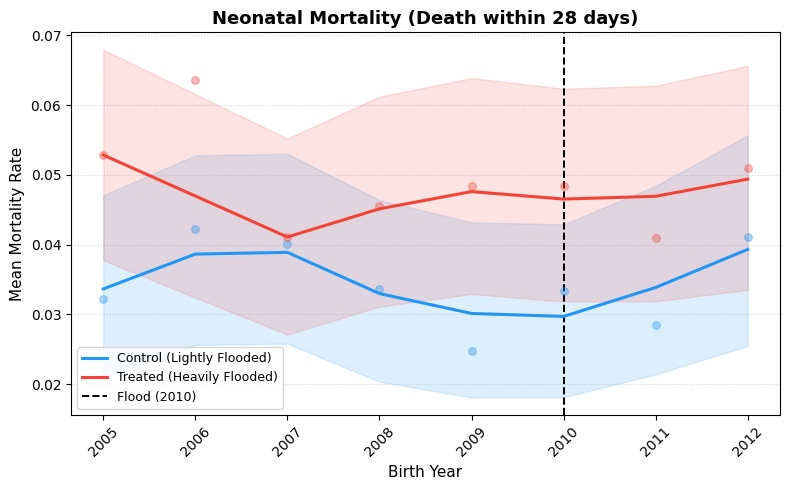

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess


def compute_annual_stats(df, outcome, group_col="treated", n_boot=500, ci=95):
    records = []
    alpha = (100 - ci) / 2
    for year in sorted(df["birth_year"].unique()):
        for grp in df[group_col].unique():
            vals = (
                df.loc[(df["birth_year"] == year) & (df[group_col] == grp), outcome]
                .dropna()
                .values
            )
            if len(vals) == 0:
                continue
            mean_val = vals.mean()
            boot_means = [
                np.random.choice(vals, size=len(vals), replace=True).mean()
                for _ in range(n_boot)
            ]
            ci_low = np.percentile(boot_means, alpha)
            ci_high = np.percentile(boot_means, 100 - alpha)
            records.append(
                {
                    "year": year,
                    "group": grp,
                    "mean": mean_val,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                }
            )
    return pd.DataFrame(records)


def smooth_series(years, values, frac=0.5):
    result = lowess(values, years, frac=frac, return_sorted=True)
    return result[:, 0], result[:, 1]


np.random.seed(42)
color_map = {0: "#2196F3", 1: "#F44336"}
label_map = {0: "Control (Lightly Flooded)", 1: "Treated (Heavily Flooded)"}

fig, ax = plt.subplots(figsize=(8, 5))
stats_df = compute_annual_stats(merged_data, "neonatal_death")

for grp in [0, 1]:
    grp_df = stats_df[stats_df["group"] == grp].sort_values("year")
    years = grp_df["year"].values.astype(float)
    means = grp_df["mean"].values
    ci_low = grp_df["ci_low"].values
    ci_high = grp_df["ci_high"].values
    color = color_map[grp]

    # Raw annual means (semi-transparent scatter)
    ax.scatter(years, means, color=color, alpha=0.35, s=30, zorder=3)

    # LOWESS smoothed trend line
    sx, sy = smooth_series(years, means)
    ax.plot(sx, sy, color=color, linewidth=2.2, label=label_map[grp], zorder=4)

    # 95% bootstrap CI as shaded region
    _, sy_low = smooth_series(years, ci_low)
    _, sy_high = smooth_series(years, ci_high)
    ax.fill_between(sx, sy_low, sy_high, color=color, alpha=0.15, zorder=2)

ax.axvline(x=2010, color="black", linestyle="--", linewidth=1.4, label="Flood (2010)")
ax.set_title(
    "Neonatal Mortality (Death within 28 days)", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Birth Year", fontsize=11)
ax.set_ylabel("Mean Mortality Rate", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_xticks(sorted(merged_data["birth_year"].unique()))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figure1_neonatal.png", dpi=150, bbox_inches="tight")
plt.show()

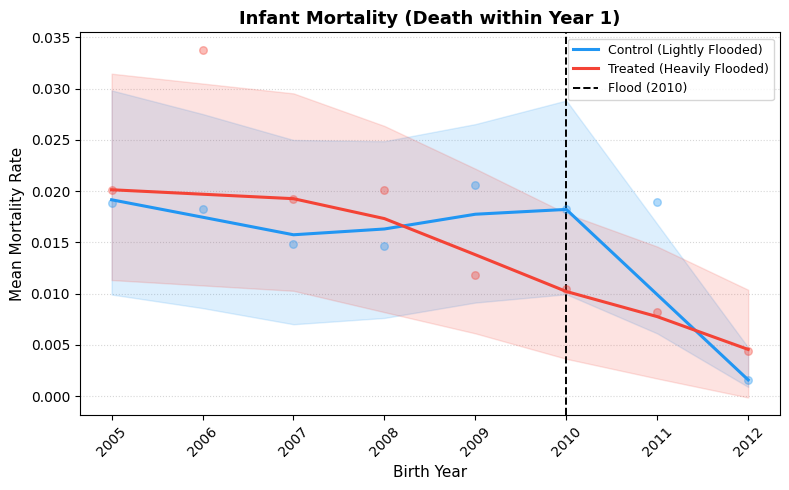

In [31]:
np.random.seed(42)

fig, ax = plt.subplots(figsize=(8, 5))
stats_df = compute_annual_stats(merged_data, "infant_death")

for grp in [0, 1]:
    grp_df = stats_df[stats_df["group"] == grp].sort_values("year")
    years = grp_df["year"].values.astype(float)
    means = grp_df["mean"].values
    ci_low = grp_df["ci_low"].values
    ci_high = grp_df["ci_high"].values
    color = color_map[grp]

    # Raw annual means (semi-transparent scatter)
    ax.scatter(years, means, color=color, alpha=0.35, s=30, zorder=3)

    # LOWESS smoothed trend line
    sx, sy = smooth_series(years, means)
    ax.plot(sx, sy, color=color, linewidth=2.2, label=label_map[grp], zorder=4)

    # 95% bootstrap CI as shaded region
    _, sy_low = smooth_series(years, ci_low)
    _, sy_high = smooth_series(years, ci_high)
    ax.fill_between(sx, sy_low, sy_high, color=color, alpha=0.15, zorder=2)

ax.axvline(x=2010, color="black", linestyle="--", linewidth=1.4, label="Flood (2010)")
ax.set_title("Infant Mortality (Death within Year 1)", fontsize=13, fontweight="bold")
ax.set_xlabel("Birth Year", fontsize=11)
ax.set_ylabel("Mean Mortality Rate", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_xticks(sorted(merged_data["birth_year"].unique()))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figure2_infant.png", dpi=150, bbox_inches="tight")
plt.show()

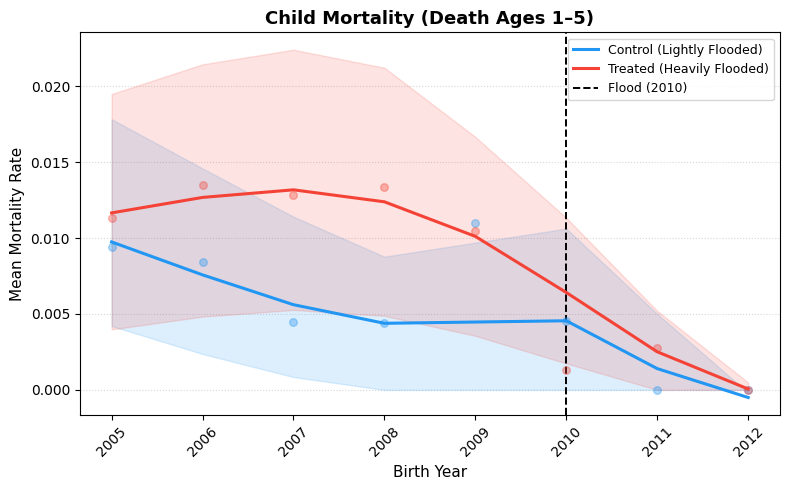

In [32]:
np.random.seed(42)

fig, ax = plt.subplots(figsize=(8, 5))
stats_df = compute_annual_stats(merged_data, "child_death")

for grp in [0, 1]:
    grp_df = stats_df[stats_df["group"] == grp].sort_values("year")
    years = grp_df["year"].values.astype(float)
    means = grp_df["mean"].values
    ci_low = grp_df["ci_low"].values
    ci_high = grp_df["ci_high"].values
    color = color_map[grp]

    # Raw annual means (semi-transparent scatter)
    ax.scatter(years, means, color=color, alpha=0.35, s=30, zorder=3)

    # LOWESS smoothed trend line
    sx, sy = smooth_series(years, means)
    ax.plot(sx, sy, color=color, linewidth=2.2, label=label_map[grp], zorder=4)

    # 95% bootstrap CI as shaded region
    _, sy_low = smooth_series(years, ci_low)
    _, sy_high = smooth_series(years, ci_high)
    ax.fill_between(sx, sy_low, sy_high, color=color, alpha=0.15, zorder=2)

ax.axvline(x=2010, color="black", linestyle="--", linewidth=1.4, label="Flood (2010)")
ax.set_title("Child Mortality (Death Ages 1–5)", fontsize=13, fontweight="bold")
ax.set_xlabel("Birth Year", fontsize=11)
ax.set_ylabel("Mean Mortality Rate", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_xticks(sorted(merged_data["birth_year"].unique()))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figure3_child.png", dpi=150, bbox_inches="tight")
plt.show()